In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling  import SMOTE
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score,classification_report,f1_score,ConfusionMatrixDisplay

In [2]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv") 

In [3]:
#handle the columns type from string to object to avoid trouble while working 
for i in df.select_dtypes("str"):
    df[i] = df[i].astype("object")

In [4]:
#show information about the data
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                  1470 non-

In [5]:
#help to show all columns
pd.set_option('display.max_columns', None)
#provides a summary of the distribution of numerical data in dataset
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,2.728571,6502.931293,14313.103401,2.693197,15.209524,3.153741,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,1.102846,4707.956783,7117.786044,2.498009,3.659938,0.360824,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,1009.000000,2094.000000,0.000000,11.000000,3.000000,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,2.000000,2911.000000,8047.000000,1.000000,12.000000,3.000000,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,3.000000,4919.000000,14235.500000,2.000000,14.000000,3.000000,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,4.000000,8379.000000,20461.500000,4.000000,18.000000,3.000000,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,4.000000,19999.000000,26999.000000,9.000000,25.000000,4.000000,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [6]:
#show the number of null value 
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [7]:
#show if there an duplicated
df.duplicated().sum()

np.int64(0)

In [8]:
#check the number of uniqe in each column
df.nunique()

Age                           43
Attrition                      2
BusinessTravel                 3
DailyRate                    886
Department                     3
DistanceFromHome              29
Education                      5
EducationField                 6
EmployeeCount                  1
EmployeeNumber              1470
EnvironmentSatisfaction        4
Gender                         2
HourlyRate                    71
JobInvolvement                 4
JobLevel                       5
JobRole                        9
JobSatisfaction                4
MaritalStatus                  3
MonthlyIncome               1349
MonthlyRate                 1427
NumCompaniesWorked            10
Over18                         1
OverTime                       2
PercentSalaryHike             15
PerformanceRating              2
RelationshipSatisfaction       4
StandardHours                  1
StockOptionLevel               4
TotalWorkingYears             40
TrainingTimesLastYear          7
WorkLifeBa

In [9]:
#show the value counts of catigorical columns
for col in df.select_dtypes(include='object'):
    print(df[col].value_counts())
    print("-"*75)

Attrition
No     1233
Yes     237
Name: count, dtype: int64
---------------------------------------------------------------------------
BusinessTravel
Travel_Rarely        1043
Travel_Frequently     277
Non-Travel            150
Name: count, dtype: int64
---------------------------------------------------------------------------
Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64
---------------------------------------------------------------------------
EducationField
Life Sciences       606
Medical             464
Marketing           159
Technical Degree    132
Other                82
Human Resources      27
Name: count, dtype: int64
---------------------------------------------------------------------------
Gender
Male      882
Female    588
Name: count, dtype: int64
---------------------------------------------------------------------------
JobRole
Sales Executive              326
Research Scientist         

In [10]:
# Eliminate constant features to improve data quality and ensure reliable analysis and modeling
df = df.drop(["EmployeeNumber","EmployeeCount","Over18","StandardHours"],axis=1)

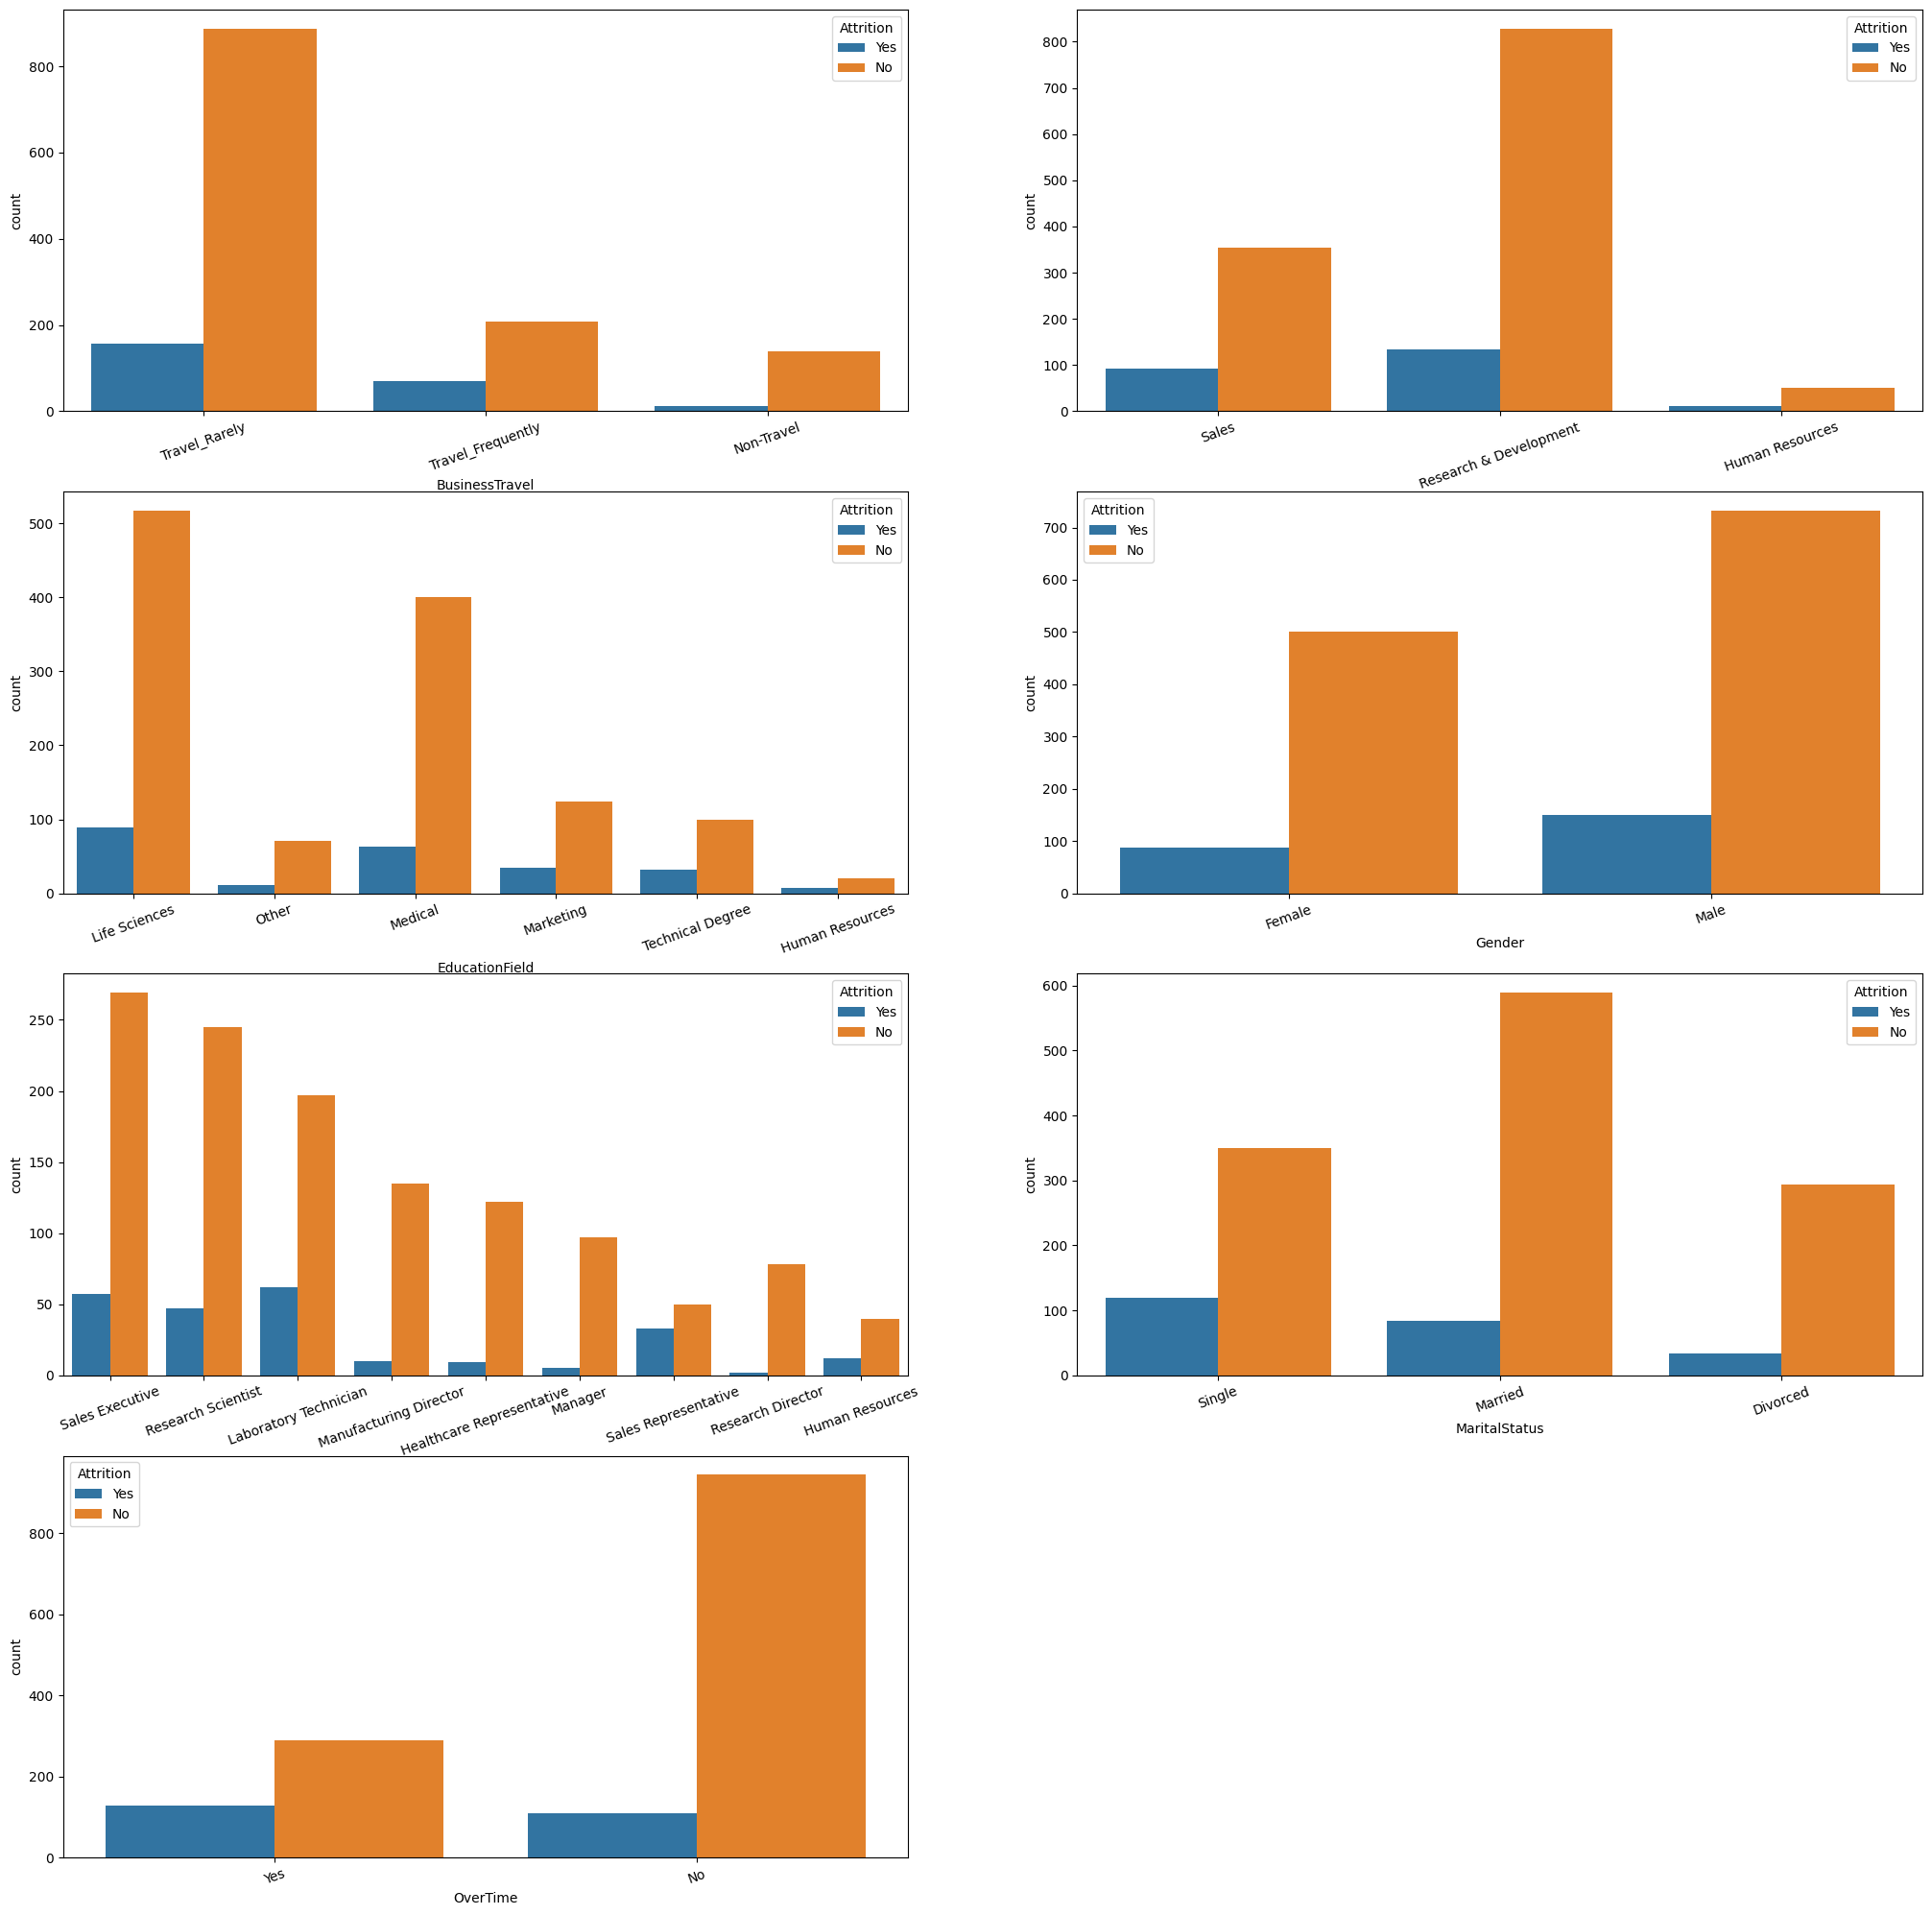

In [11]:
## Visualize the relationship between categorical features and employee attrition to identify patterns and factors associated with employee turnover
plt.figure(figsize=(25,25))
k=0
for i in ['BusinessTravel', 'Department', 'EducationField', 'Gender','JobRole', 'MaritalStatus', 'OverTime']:
    plt.subplot(4,2,k+1)
    sns.countplot(x=i,hue="Attrition",data=df)
    plt.xticks(rotation = 20)
    k+=1
    

<Axes: >

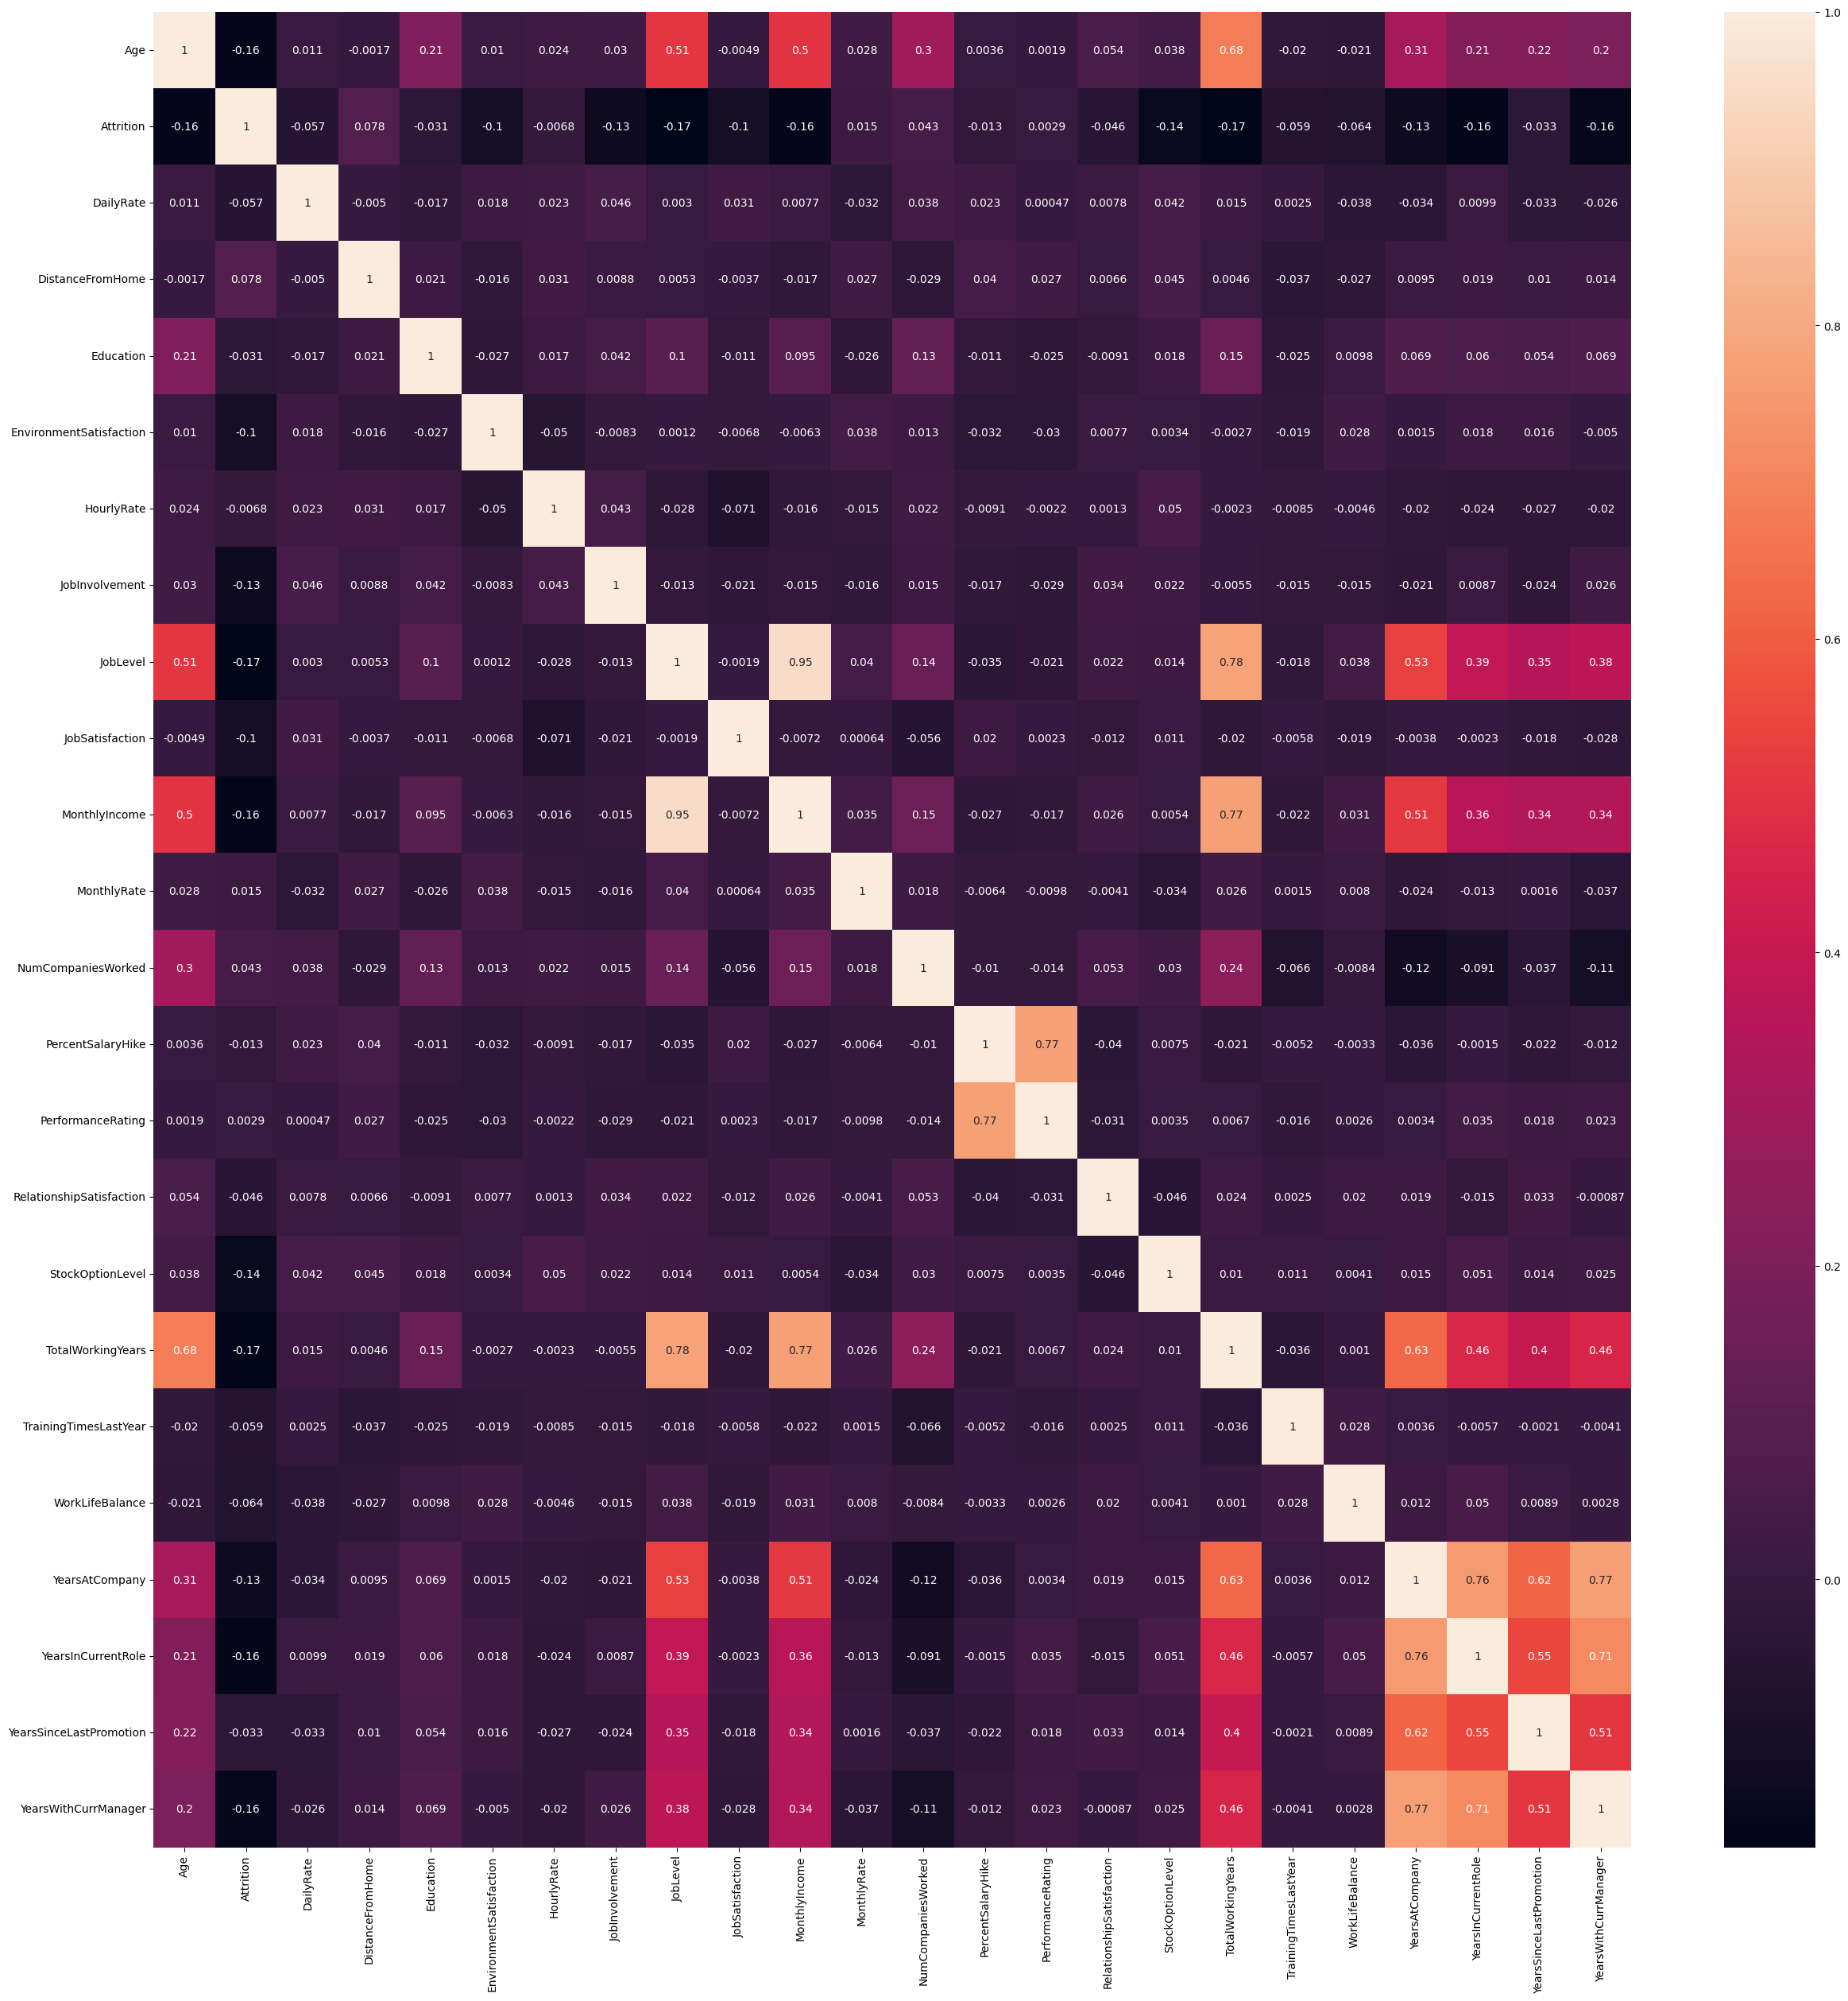

In [12]:
#convert the target to numeric
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})
#show the corrleation between numeric columns and the target
plt.figure(figsize=(30,30))
sns.heatmap(df.corr(numeric_only=True),annot = True)

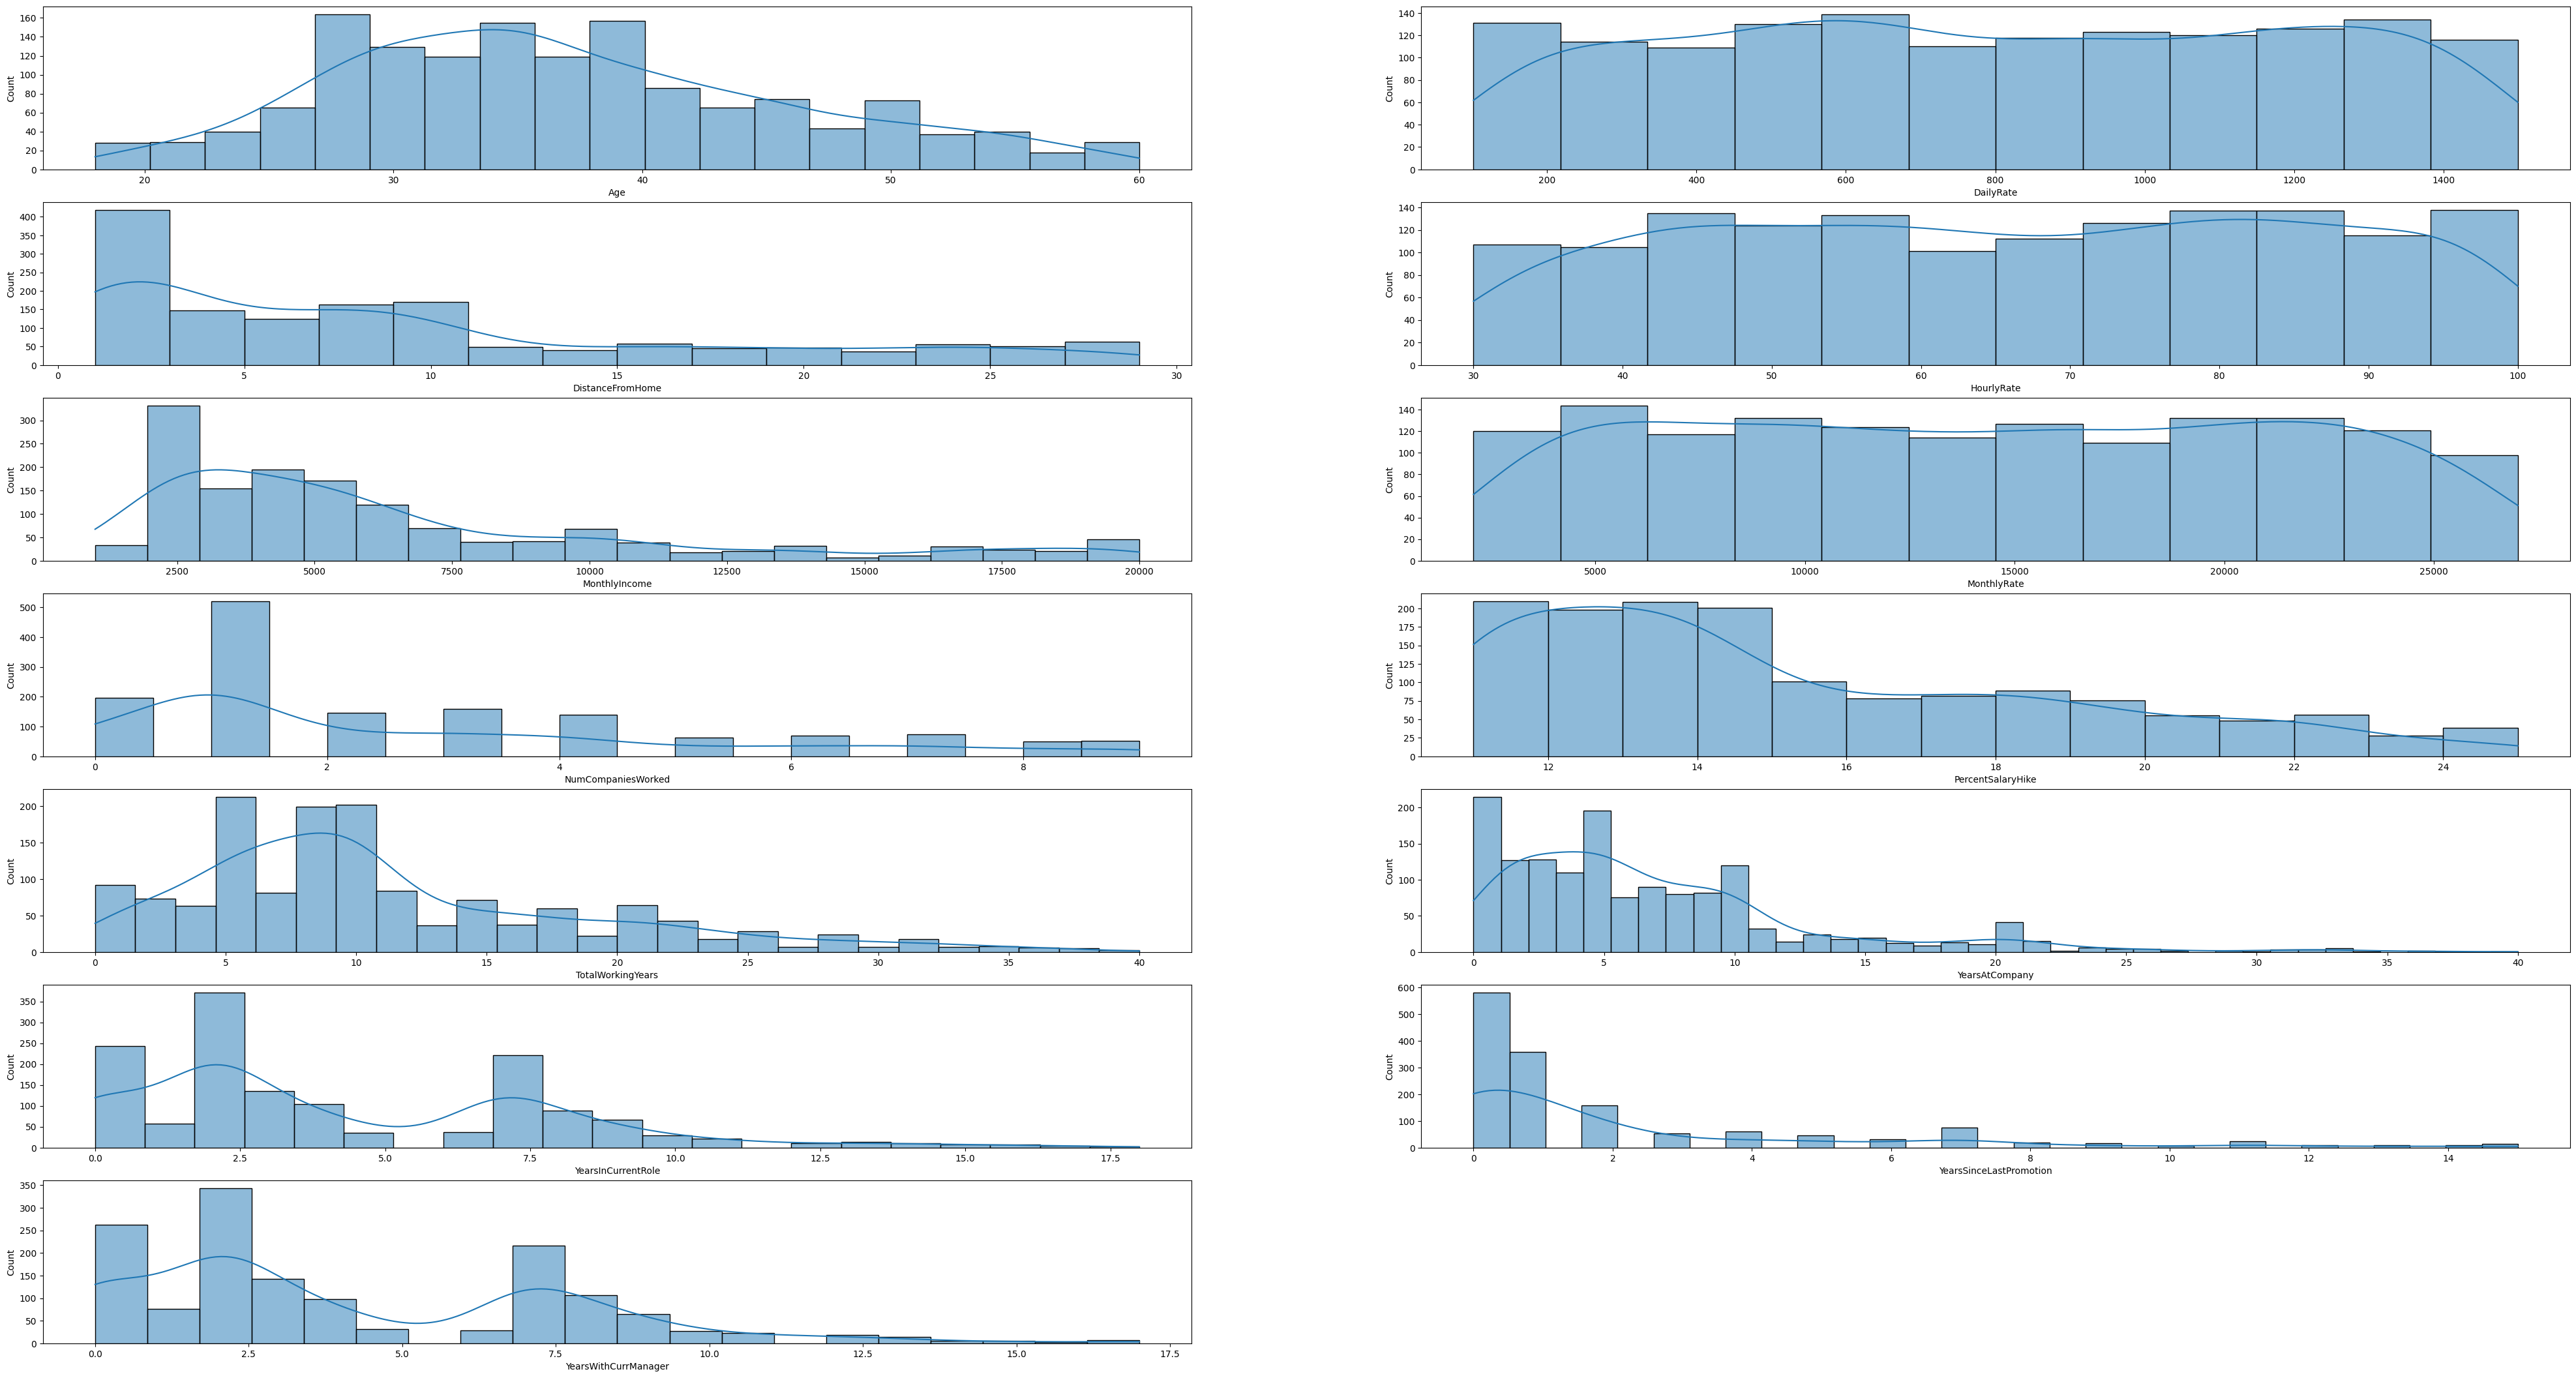

In [13]:
plt.figure(figsize=(50,50))
k=0
for i in ["Age","DailyRate","DistanceFromHome","HourlyRate",
          "MonthlyIncome","MonthlyRate","NumCompaniesWorked","PercentSalaryHike","TotalWorkingYears",
          "YearsAtCompany","YearsInCurrentRole","YearsSinceLastPromotion","YearsWithCurrManager"]:
    plt.subplot(13,2,k+1)
    sns.histplot(df[i],kde=True)
    k+=1

In [14]:
#see the skew of the data
for i in ["Age","DailyRate","DistanceFromHome","HourlyRate",
          "MonthlyIncome","MonthlyRate","NumCompaniesWorked","PercentSalaryHike","TotalWorkingYears",
          "YearsAtCompany","YearsInCurrentRole","YearsSinceLastPromotion","YearsWithCurrManager"]:
    print(i,df[i].skew())

Age 0.4132863018563338
DailyRate -0.003518568352325854
DistanceFromHome 0.9581179956568269
HourlyRate -0.03231095290044942
MonthlyIncome 1.3698166808390662
MonthlyRate 0.018577807891132458
NumCompaniesWorked 1.026471111968205
PercentSalaryHike 0.8211279755780908
TotalWorkingYears 1.1171718528128527
YearsAtCompany 1.7645294543422085
YearsInCurrentRole 0.9173631562908262
YearsSinceLastPromotion 1.9842899833524859
YearsWithCurrManager 0.8334509919918475


In [15]:
cat_cols = ['BusinessTravel', 'Department', 'EducationField',
            'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

encoder = OneHotEncoder(drop='first', sparse_output=False)
encoded_array = encoder.fit_transform(df[cat_cols])
encoded_df = pd.DataFrame(encoded_array,
                           columns=encoder.get_feature_names_out(),
                           index=df.index)
df = df.drop(columns=cat_cols)
df = pd.concat([df, encoded_df], axis=1)

In [16]:
x=df.drop("Attrition",axis=1)
y=df.Attrition
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2)

In [17]:
transform_cols = ['Age', 'DailyRate', 'DistanceFromHome', 'Education',
                  'EnvironmentSatisfaction', 'HourlyRate',
                  'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome',
                  'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike',
                  'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel',
                  'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
                  'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
                  'YearsWithCurrManager']

pt = PowerTransformer(method='yeo-johnson')
x_train[transform_cols] = pt.fit_transform(x_train[transform_cols])
x_test[transform_cols] = pt.transform(x_test[transform_cols])  

In [18]:
smote = SMOTE()
x_train_res, y_train_res = smote.fit_resample(x_train, y_train)

In [19]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import f1_score
import numpy as np

best_gb, best_f1 = None, 0

neg = np.sum(y_train_res == 0)
pos = np.sum(y_train_res == 1)
ratio = neg / pos

for n_estimators in [100, 200, 300]:
    for lr in [0.05, 0.1, 0.2]:
        for max_depth in [3, 5, 7]:
            model = GradientBoostingClassifier(
                n_estimators=n_estimators,
                learning_rate=lr,
                max_depth=max_depth,
                subsample=0.8,
                min_samples_leaf=5,
                random_state=42
            )
            model.fit(x_train_res, y_train_res)

            probs = model.predict_proba(x_test)[:, 1]
            preds = (probs >= 0.40).astype(int)
            f1 = f1_score(y_test, preds)
            if f1 > best_f1:
                best_f1 = f1
                best_gb = model

print(f"Best Gradient Boosting F1: {best_f1:.4f}")

Best Gradient Boosting F1: 0.6286


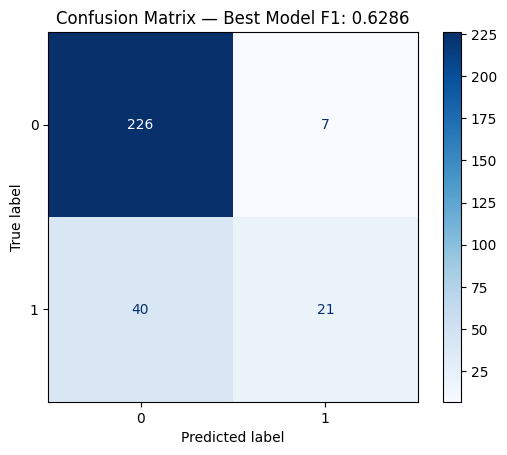

In [24]:
ConfusionMatrixDisplay.from_estimator(best_gb, x_test, y_test, cmap='Blues')
plt.title(f"Confusion Matrix — Best Model F1: {best_f1:.4f}")
plt.show()

In [26]:
import pickle
import json
pickle.dump(best_gb, open("model.pkl", "wb"))
pickle.dump(pt, open("power_transformation.pkl", "wb"))
pickle.dump(encoder,open("encoding.pkl","wb"))
feature_names = list(x.columns)
with open("feature_names.json", "w") as f:
    json.dump(feature_names, f)
print(f"Saved {len(feature_names)} feature names")

Saved 44 feature names


In [3]:
import pandas as pd
df1 = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv") 


In [9]:
pd.set_option('display.max_columns', None)
df1[df1["Attrition"]=="Yes"]

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
14,28,Yes,Travel_Rarely,103,Research & Development,24,3,Life Sciences,1,19,3,Male,50,2,1,Laboratory Technician,3,Single,2028,12947,5,Y,Yes,14,3,2,80,0,6,4,3,4,2,0,3
21,36,Yes,Travel_Rarely,1218,Sales,9,4,Life Sciences,1,27,3,Male,82,2,1,Sales Representative,1,Single,3407,6986,7,Y,No,23,4,2,80,0,10,4,3,5,3,0,3
24,34,Yes,Travel_Rarely,699,Research & Development,6,1,Medical,1,31,2,Male,83,3,1,Research Scientist,1,Single,2960,17102,2,Y,No,11,3,3,80,0,8,2,3,4,2,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1438,23,Yes,Travel_Frequently,638,Sales,9,3,Marketing,1,2023,4,Male,33,3,1,Sales Representative,1,Married,1790,26956,1,Y,No,19,3,1,80,1,1,3,2,1,0,1,0
1442,29,Yes,Travel_Rarely,1092,Research & Development,1,4,Medical,1,2027,1,Male,36,3,1,Research Scientist,4,Married,4787,26124,9,Y,Yes,14,3,2,80,3,4,3,4,2,2,2,2
1444,56,Yes,Travel_Rarely,310,Research & Development,7,2,Technical Degree,1,2032,4,Male,72,3,1,Laboratory Technician,3,Married,2339,3666,8,Y,No,11,3,4,80,1,14,4,1,10,9,9,8
1452,50,Yes,Travel_Frequently,878,Sales,1,4,Life Sciences,1,2044,2,Male,94,3,2,Sales Executive,3,Divorced,6728,14255,7,Y,No,12,3,4,80,2,12,3,3,6,3,0,1


In [11]:
df1["Education"].unique()

array([2, 1, 4, 3, 5])